# 在 Colab 中打开
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH02/ch02_hierarchical_agent_teams.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 关于这个 Notebook

这个 Notebook 使用 **LangGraph** 和 **LangChain** 构建一个 hierarchical agent system（分层智能体系统）：它能够进行网页研究、抓取页面、搜索专利、运行代码，并让多个智能体协作撰写报告并持久化到磁盘。核心示范是：如何在一个 top-level supervisor（顶层监督者）之下组合多个 subgraph（子图），同时让工具、角色和状态保持显式。

## 它展示了什么

* **两个由 supervisor（监督者）协调的专业团队**

  1. **Research team（研究团队）**：包含搜索、网页抓取、Exa 语义搜索和 Google Patents
  2. **Document writing team（文档写作团队）**：包含大纲创建、文档读写、编辑，以及用于简单图表的 Python REPL
* **Top-level orchestrator（顶层编排器）**：在两个团队之间路由任务并汇总结果
* **工具组合**：Tavily、SerpAPI、Exa、WebBaseLoader 抓取和 Python REPL
* **File persistence（文件持久化）**：把大纲和最终报告写入工作目录
* **Streaming runs（流式运行）**：逐步打印执行更新，并为各团队及 supervisor graph（监督图）展示 Mermaid PNG 图预览

## 你将运行什么

1. 定义研究工具

   * `tavily_tool`：获取搜索结果
   * `scrape_webpages`：抓取并拼接网页内容
   * `patent_search`：通过 SerpAPI Google Patents 搜索专利
   * `exa_search_tool`：执行 neural search（神经搜索）并返回高亮片段
2. 定义文档工具

   * `create_outline`、`read_document`、`write_document`、`edit_document`：在沙箱化工作目录中操作
   * `python_repl_tool`：进行快速计算，或生成并输出简单图表
3. 使用 `create_react_agent` 构建 **worker nodes（工作节点）**，并创建通过 structured routing（结构化路由）选择下一位 worker 或结束流程的 **LLM supervisors**。
4. 编译三个图

   * `research_graph`：负责网页研究和专利检索
   * `paper_writing_graph`：负责大纲和写作，可选生成图表
   * `super_graph`：端到端编排两个团队
5. 执行示例

   * 让研究团队研究 AI agents 与专利
   * 让写作团队把一首诗写入磁盘
   * 运行完整任务，生成一篇约 800 词的半导体白皮书，包含专利链接与来源，并保存为 `semiconductor_whitepaper.txt`

## 它如何工作

* **Supervisors（监督者）**：小型 LLM router（路由器）通过结构化输出，从固定 worker 集合中选择下一位执行者，或返回 `FINISH`。
* **Workers（工作智能体）**：绑定特定工具集和 Prompt 的 ReAct 风格智能体。每个 worker 返回一条简洁消息，再交还 supervisor。
* **State（状态）**：使用 `MessagesState` 加一个简单的 `next` 字段。消息可以跨团队流动，让顶层 supervisor 协调任务。
* **Routing（路由）**：通过 `Command(goto=..., update=...)` 在节点间移动，并同时把结果追加到状态。
* **Persistence（持久化）**：文件工具在 `WORKING_DIRECTORY` 下读写；最终任务会把完整报告写入磁盘。

## 为什么采用这种模式

* 清晰的职责分离让行为更可预测、更易测试。
* Supervisor 让控制流保持显式且可审计。
* 每个 worker 的工具使用范围受限，可以减少 Prompt 膨胀并提高可靠性。
* 顶层图可以组合多个团队，而不需要耦合它们的内部实现细节。

## 如何扩展与调整

* 在研究与写作之间增加 citation validator（引用验证器）。
* 替换或增加搜索服务提供商。
* 用 sandboxed executor（沙箱执行器）替换 Python REPL。
* 使用 LangSmith 持久化 checkpoint（检查点）和 trace（轨迹），用于调试与评估。

## 运行要求与说明

* 必需密钥：`OPENAI_API_KEY`、`TAVILY_API_KEY`、`SERPAPI_API_KEY`、`EXA_API_KEY`。
* 网页结果和专利列表会随时间变化，不同运行的输出可能不同。
* 文件系统工具会写入工作目录。处理不可信内容时，请使用沙箱或 Docker 环境。
* 流式输出会打印中间更新，便于追踪决策过程与工具调用。


# 依赖项

In [4]:
!pip install -q \
    langchain==0.3.27 \
    langgraph==0.6.7 \
    langchain-openai==0.3.33 \
    langchain_experimental==0.3.4 \
    langchain_community==0.3.30 \
    langchain-tavily==0.2.11 \
    exa_py==1.15.6 \
    python-dotenv==1.1.1


# API Key 配置

In [ ]:
# 方案 1（推荐）：在项目目录中创建 `.env` 文件，并写入：
# OPENAI_API_KEY=your_openai_key_here
# TAVILY_API_KEY=your_tavily_key_here
# SERPAPI_API_KEY=your_serpapi_key_here
# EXA_API_KEY=your_exa_key_here
#
# 方案 2：直接通过 Notebook magic 命令设置：
# %env OPENAI_API_KEY=your_openai_key_here
# %env TAVILY_API_KEY=your_tavily_key_here
# %env SERPAPI_API_KEY=your_serpapi_key_here
# %env EXA_API_KEY=your_exa_key_here

from dotenv import load_dotenv
import os

# 如果存在 `.env`，则从中加载。
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
SERPAPI_API_KEY = os.getenv("SERPAPI_API_KEY")
EXA_API_KEY = os.getenv("EXA_API_KEY")

# Fallback（回退方案）：如果仍缺少密钥，则交互式询问。
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

if not TAVILY_API_KEY:
    print("⚠️ TAVILY_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    TAVILY_API_KEY = input("Enter your TAVILY_API_KEY: ").strip()

if not SERPAPI_API_KEY:
    print("⚠️ SERPAPI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    SERPAPI_API_KEY = input("Enter your SERPAPI_API_KEY: ").strip()

if not EXA_API_KEY:
    print("⚠️ EXA_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    EXA_API_KEY = input("Enter your EXA_API_KEY: ").strip()

print("✅ API keys loaded successfully!")


<div class="admonition tip">
    <p class="admonition-title">为 LangGraph 开发配置 <a href="https://smith.langchain.com">LangSmith</a></p>
    <p style="padding-top: 5px;">
        注册 LangSmith 后，可以更快发现问题并改进 LangGraph 项目的性能。LangSmith 可利用 trace data（轨迹数据）来调试、测试和监控基于 LangGraph 构建的 LLM 应用；入门方式请参阅<a href="https://docs.smith.langchain.com">官方文档</a>。
    </p>
</div>

# 导入依赖

In [ ]:
from __future__ import annotations

# Python 标准库（stdlib）
import json
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Any, Annotated, Dict, List, Literal, Optional, Sequence
from typing_extensions import TypedDict

# 第三方依赖（third party）
from exa_py import Exa
from langchain_openai import ChatOpenAI

# LangChain
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import BaseMessage, HumanMessage, trim_messages
from langchain_core.tools import tool

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import SerpAPIWrapper

from langchain_experimental.utilities import PythonREPL

from langchain_tavily import TavilySearch

# LangGraph
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command


# 创建工具

每个团队都会由一个或多个智能体组成，每个智能体又可以拥有一个或多个工具。下面先统一定义各团队将使用的工具。

我们从研究团队开始。

**ResearchTeam 工具**

研究团队可以使用搜索引擎和 URL scraper（网页抓取器）在互联网上查找信息。你也可以在下面增加更多能力，以提升团队表现。

**Document writing team tools（文档写作团队工具）**

接下来，为文档写作团队提供一组可调用工具。
下面先定义几个最基础的文件访问工具。

需要注意：这会让智能体直接访问文件系统，在某些场景下并不安全；这里的工具描述也还没有针对性能做专门优化。

In [ ]:
# 定义持久化工作目录
WORKING_DIRECTORY = Path("/content/working_directory")

# 确保工作目录已经存在
if not WORKING_DIRECTORY.exists():
    WORKING_DIRECTORY.mkdir(parents=True)
    print(f"Created working directory: {WORKING_DIRECTORY}")
else:
    print(f"Working directory already exists: {WORKING_DIRECTORY}")


@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

@tool("patent_search")
def patent_search(query: str) -> str:
    """Search with Google SERP API by a query to fine news about patents related to the query."""
    params = {
        "engine": "google_patents",
        "gl": "us",
        "hl": "en",
        }
    patent_search = SerpAPIWrapper(params=params, serpapi_api_key=serp_api_key)
    return patent_search.run(query)


@tool("exa_search_tool")
def exa_search_tool(question: str) -> str:
    """Tool using Exa's Python SDK to run semantic search and return result highlights."""
    exa = Exa(exa_api_key)

    response = exa.search_and_contents(
        question,
        type="neural",
        use_autoprompt=True,
        num_results=3,
        highlights=True
    )

    results = []
    for idx, eachResult in enumerate(response.results):
        result = {
            "Title": eachResult.title,
            "URL": eachResult.url,
            "Highlight": "".join(eachResult.highlights)
        }
        results.append(result)

    return json.dumps(results)

# 从 LangChain 加载 Tavily Search Wrapper
tavily_tool = TavilySearchResults(
    max_results= 5,
    search_depth = "advanced"
    )

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


# 警告：这里会在本地执行代码；未使用沙箱时可能存在安全风险

repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

Working directory already exists: /content/working_directory


# 辅助工具函数（Helper Utilities）

接下来创建几个辅助函数，让下面这些操作写起来更简洁：

1. 创建 worker agent（工作智能体）。
2. 为子图创建 supervisor（监督者）。

这样可以减少后面图组合代码的样板内容，更容易看清整个流程到底是怎样连接起来的。

In [ ]:
class State(MessagesState):
    next: str


def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

In [ ]:

def make_react_worker_node(
    *,
    llm: ChatOpenAI,
    name: str,
    tools: list,
    prompt: str | None = None,
    goto: str = "supervisor",
):
    agent = create_react_agent(llm, tools=tools, prompt=prompt)

    def node(state: State) -> Command[Literal["supervisor"]]:
        result: Dict[str, Any] = agent.invoke(state)
        msgs: Sequence[BaseMessage] = result.get("messages", [])
        content = getattr(msgs[-1], "content", "") if msgs else ""
        return Command(
            update={"messages": [HumanMessage(content=content, name=name)]},
            goto=goto,
        )

    return node


## 定义 Agent Teams（智能体团队）

现在可以开始定义真正的 hierarchical teams（分层团队）了——也就是“选择你的队员”。

### Research Team（研究团队）

研究团队包含搜索智能体和网页抓取 `research_agent`，它们作为两个 worker nodes（工作节点）。下面会创建这些节点以及团队 supervisor（监督者）。

必要组件创建完成后，定义它们之间的交互就很直接了：把节点加入团队图，再定义 edges（边），由边决定节点之间如何转换。

## LLM 配置

In [ ]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [ ]:
# Prompt 用于保持各角色职责清晰
SEARCH_PROMPT = """Role: Web researcher. Use the search tool and return a
concise research note with sources. No follow-up questions."""

SCRAPER_PROMPT = """Role: Web scraper. Use the scraping tool to fetch details
from given URLs and summarize key findings. No follow-up questions."""

EXA_PROMPT = """Role: Research assistant. You can search for all recent info
on Exa Search. Your response should clearly articulate the key points you found."""

PATENT_PROMPT = """Role: Market researcher with 20 years of experience.
You are very knowledgeable in patent research and in finding up-to-date info
about patents using the Google Patents API."""

# 把各 worker 加入 specs 列表
specs = [
    dict(
        name="search",
        tools=[tavily_tool],
        prompt=SEARCH_PROMPT,
    ),
    dict(
        name="web_scraper",
        tools=[scrape_webpages],
        prompt=SCRAPER_PROMPT,
    ),
    dict(
        name="exa_search",
        tools=[exa_search_tool],
        prompt=EXA_PROMPT,
    ),
    dict(
        name="patent_research",
        tools=[patent_search],
        prompt=PATENT_PROMPT,
    ),
]

nodes = {s["name"]: make_react_worker_node(llm=llm, **s) for s in specs}

search_node = nodes["search"]
web_scraper_node = nodes["web_scraper"]
exa_search_node = nodes["exa_search"]
patent_research_node = nodes["patent_research"]

# 能够协调四个 worker 的 supervisor
research_supervisor_node = make_supervisor_node(
    llm, ["search", "web_scraper", "exa_search", "patent_research"]
)


In [ ]:
research_builder = StateGraph(State)

# 注册节点
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scraper", web_scraper_node)
research_builder.add_node("exa_search", exa_search_node)
research_builder.add_node("patent_research", patent_research_node)

# 定义边
research_builder.add_edge(START, "supervisor")
research_builder.add_edge("search", "supervisor")
research_builder.add_edge("web_scraper", "supervisor")
research_builder.add_edge("exa_search", "supervisor")
research_builder.add_edge("patent_research", "supervisor")

research_graph = research_builder.compile()

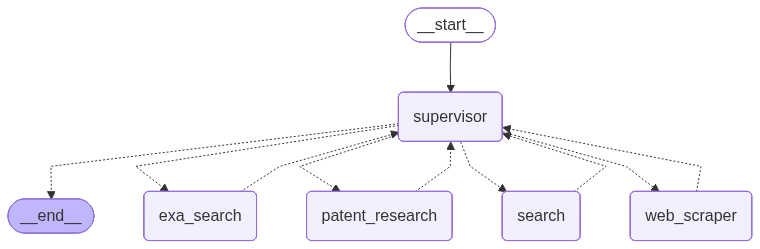

In [ ]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))

We can give this team work directly. Try it out below.

In [ ]:
for s in research_graph.stream(
    {"messages": [("user", "What are AI agents? Are there any patents out there about LLM agents?")]},
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'search'}}
---
{'search': {'messages': [HumanMessage(content='### What are AI Agents?\n\nAI agents are software programs designed to interact with their environment, collect data, and perform tasks autonomously to achieve specific goals. They can process multimodal information such as text, voice, video, and audio, and are capable of conversing, reasoning, learning, and making decisions. AI agents are used in various applications, including robotics, gaming, and intelligent systems, where they enhance decision-making and adaptability through techniques like machine learning. They can be integrated into platforms like Google Cloud, AWS, and Microsoft 365 to perform tasks such as customer service, data analysis, and personalized user interactions [Google Cloud](https://cloud.google.com/discover/what-are-ai-agents), [IBM](https://www.ibm.com/think/topics/ai-agents), [AWS](https://aws.amazon.com/what-is/ai-agents/).\n\n### Patents on LLM Agents\n\nThere are several 

### Document Writing Team（文档写作团队）

下面用类似的方法创建文档写作团队。不同之处在于，这一次会给每个智能体分配不同的文件写入工具。

需要注意：这里给智能体开放了文件系统访问权限，并非在所有场景下都安全。

各个对象创建完成后，就可以把它们组合成图。

In [ ]:
specs = [
    dict(name="doc_writer",
         tools=[write_document, edit_document, read_document],
         prompt="You can read, write and edit documents based on note-taker's outlines. Don't ask follow-up questions."),
    dict(name="note_taker",
         tools=[create_outline, read_document],
         prompt="You can read documents and create outlines for the document writer. Don't ask follow-up questions."),
    dict(name="chart_generator",
         tools=[read_document, python_repl_tool],
         prompt=None),
]

nodes = {s["name"]: make_react_worker_node(llm=llm, **s) for s in specs}
doc_writing_node = nodes["doc_writer"]
note_taking_node = nodes["note_taker"]
chart_generating_node = nodes["chart_generator"]


doc_writing_supervisor_node = make_supervisor_node(
    llm, ["doc_writer", "note_taker", "chart_generator"]
)


In [ ]:
# 在这里创建图
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.add_edge(START, "supervisor")
paper_writing_graph = paper_writing_builder.compile()

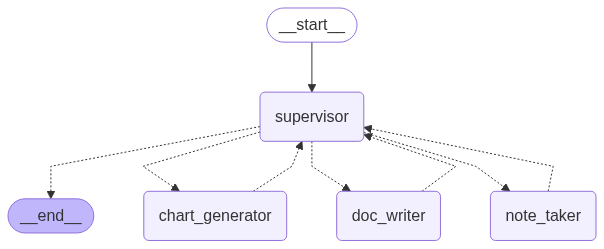

In [ ]:
from IPython.display import Image, display

display(Image(paper_writing_graph.get_graph().draw_mermaid_png()))

In [ ]:
for s in paper_writing_graph.stream(
    {
        "messages": [
            (
                "user",
                "Write an outline for poem about cats and then write the poem to disk as txt file.",
            )
        ]
    },
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'note_taker'}}
---
{'note_taker': {'messages': [HumanMessage(content='The outline for the poem about cats has been saved as "poem_about_cats.txt".', additional_kwargs={}, response_metadata={}, name='note_taker', id='efe07584-0312-4cf6-b130-a0ba10e6e983')]}}
---
{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='The outline for the poem about cats has been written to the file "poem_about_cats.txt".', additional_kwargs={}, response_metadata={}, name='doc_writer', id='1c1c839e-0bd5-4faa-9ae5-d685bcaecacc')]}}
---
{'supervisor': {'next': 'note_taker'}}
---
{'note_taker': {'messages': [HumanMessage(content='The outline for the poem about cats has been successfully saved to "poem_about_cats.txt".', additional_kwargs={}, response_metadata={}, name='note_taker', id='c15724da-1300-4028-be31-46fcba007a77')]}}
---
{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='The outline for the poem

## 增加层级（Add Layers）

这个设计采用 top-down planning policy（自顶向下的规划策略）。前面已经创建了两个图，现在还需要决定工作如何在这两个图之间路由。

因此，我们再创建**第三个图**来编排前两个图，并加入连接逻辑，明确顶层 state（状态）如何在不同图之间共享。

In [ ]:
from langchain_core.messages import BaseMessage

llm = ChatOpenAI(model="gpt-4o")

teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

In [ ]:
def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor",
    )


def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor",
    )


# 定义顶层图。
super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

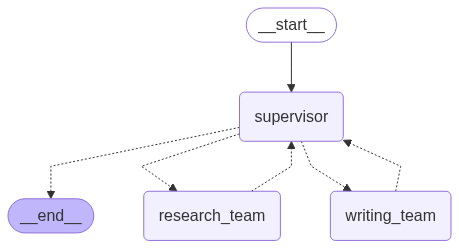

In [ ]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))

In [ ]:
# Tell the agents exactly what to do, including file name for persistence
TARGET_FILE = "semiconductor_whitepaper.txt"

TASK_MSG = f"""
Write an 800-word research report white paper on semiconductor development.
Start with an executive summary of your findings.
Search for relevant recent patents and include links to them.
IMPORTANT: Provide links to all your sources.
Finally, save the full report to disk as a .txt file using the write_document tool.
Use file_name="{TARGET_FILE}".
"""

# 使用新的指令流式运行图
for step in super_graph.stream(
    {
        "messages": [
            ("user", TASK_MSG.strip())
        ],
    },
    {"recursion_limit": 150},
):
    print(step)
    print("---")


{'supervisor': {'next': 'research_team'}}
---
{'research_team': {'messages': [HumanMessage(content="**Executive Summary**\n\nThe semiconductor industry is experiencing rapid advancements, driven by significant investments in research and development, as well as supportive legislative measures like the CHIPS Act. In 2023, the U.S. Patent and Trademark Office granted over 10,000 semiconductor-related patents, highlighting the sector's dynamic innovation landscape. Major players such as Samsung Electronics have been at the forefront, securing thousands of patents in semiconductor manufacturing. This white paper explores recent developments in semiconductor technology, the impact of legislative measures, and the competitive patent landscape.\n\n**Introduction**\n\nSemiconductors are the backbone of modern electronics, powering everything from smartphones to advanced computing systems. The industry's growth is fueled by continuous innovation and strategic investments. This report delves int